# Question 2

### Mise en place


In [18]:
!pip install numpy
!pip install pandas
!pip install "networkx >= 2.6"
!pip install matplotlib


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
import csv 
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
from packaging import version
import sys 

print("Python version:", sys.version)
print("networkx version:", nx.__version__)

# assert networkx version is greater or equal to 2.6
assert version.parse(nx.__version__) >= version.parse("3.0")

# assert python version is greater that 3.7
assert sys.version_info[0] == 3
assert sys.version_info[1] >= 7 

# If working in colab mount the drive filesystem 
if 'google.colab' in str(get_ipython()):
    print('Working in colab')
    
    from google.colab import drive
    drive.mount('/content/drive')
else:
    print("working locally")

Python version: 3.11.11 (main, Mar 14 2026, 01:14:19) [GCC 12.2.0]
networkx version: 3.6.1
working locally


## Partie A

In [21]:
def degree_distribution(G, weight=None, bins='auto'):
    """Retourne l'histogramme (densité) et les bords de bins
    Calcul de la séquence des degrés en tenant compte du poids si fourni."""
    degree_sequence = sorted([d for _, d in G.degree(weight=weight)], reverse=True)
    hist, bin_edges = np.histogram(degree_sequence, density=True, bins=bins)
    return hist, bin_edges

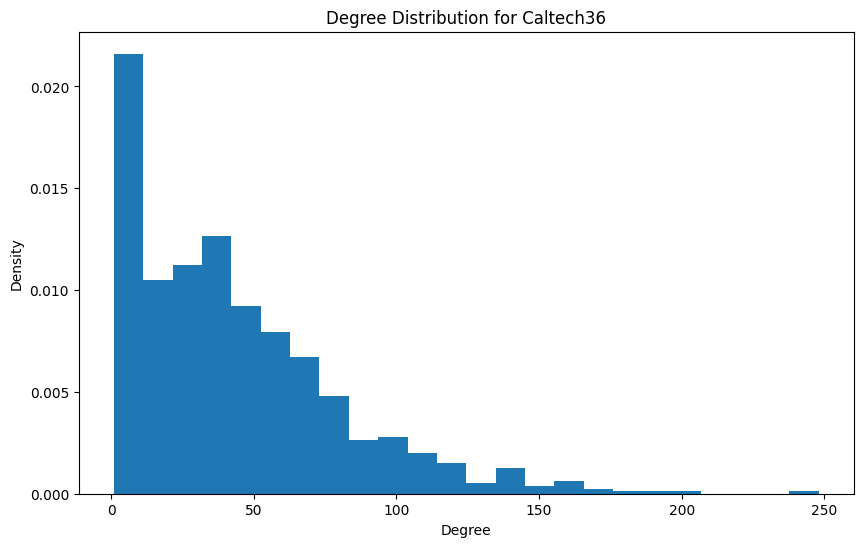

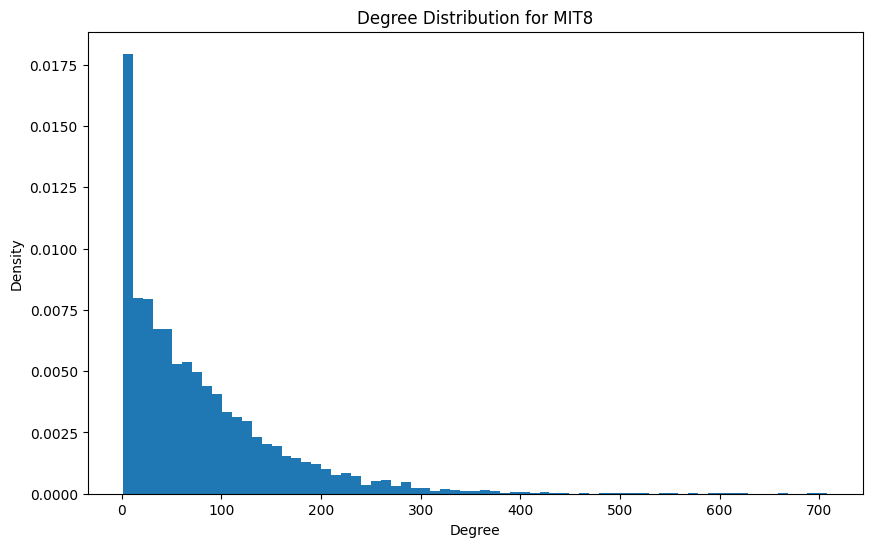

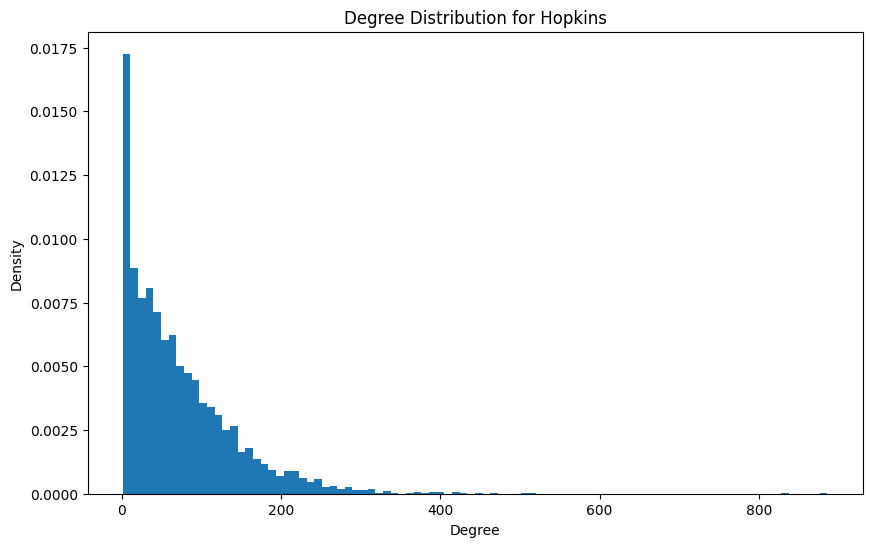

In [22]:
def print_degree_distribution(G, title, weight=None, bins='auto'):
    hist, bin_edges = degree_distribution(G, weight=weight, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    widths = bin_edges[1:] - bin_edges[:-1]

    plt.figure(figsize=(10, 6))
    plt.bar(bin_centers, hist, width=widths, align='center')
    plt.xlabel("Degree")
    plt.ylabel("Density")
    plt.title(f"Degree Distribution for {title}")
    plt.show()

GCaltech = nx.read_gml("data/Caltech36.gml")
print_degree_distribution(GCaltech, "Caltech36")

GMIT8 = nx.read_gml("data/MIT8.gml")
print_degree_distribution(GMIT8, "MIT8")

GHopkins = nx.read_gml("data/Johns Hopkins55.gml")
print_degree_distribution(GHopkins, "Hopkins")

In [ ]:
def vertexCC(G, v):
    neighbors = list(G.neighbors(v))
    deg_ne = len(neighbors)

    edges = 0.0
    for i in range(deg_ne):
        for j in range(i + 1, deg_ne):
            if G.has_edge(neighbors[i], neighbors[j]):
                edges += 1

    if edges == 0.0:
        return 0.0
    else : 
        return edges / (deg_ne * (deg_ne - 1) / 2)

def global_clustering(G):
    A = nx.to_numpy_array(G)
    num_triangle = np.trace(np.linalg.matrix_power(A, 3)) / 6
    A2 = np.linalg.matrix_power(A, 2)
    num_triple = (A2.sum() - np.trace(A2)) / 2
    return 3 * num_triangle / num_triple


def average_clustering(G):
    CC = [vertexCC(G, n) for n in G.nodes()]
    return np.array(CC).mean()

def edge_density(G):
    return nx.density(G)




In [ ]:
print("Caltech :")
print(f"  Global clustering coefficient: {global_clustering(GCaltech)}")
print(f"  Mean local clustering coefficient: {average_clustering(GCaltech)}")
print(f"  Edge density: {edge_density(GCaltech)}")

print("MIT8 :")
print(f"  Global clustering coefficient: {global_clustering(GMIT8)}")
print(f"  Mean local clustering coefficient: {average_clustering(GMIT8)}")
print(f"  Edge density: {edge_density(GMIT8)}")

print("Johns Hopkins :")
print(f"  Global clustering coefficient: {global_clustering(GHopkins)}")
print(f"  Mean local clustering coefficient: {average_clustering(GHopkins)}")
print(f"  Edge density: {edge_density(GHopkins)}")

Caltech :
  Global clustering coefficient: 0.2912826901150874
  Mean local clustering coefficient: 0.4092943904851723
  Edge density: 0.05640442132639792
MIT8 :
  Global clustering coefficient: 0.18028845093502427
  Mean local clustering coefficient: 0.271218741950132
  Edge density: 0.012118119495041378
Johns Hopkins :
  Global clustering coefficient: 0.19316123901594015
  Mean local clustering coefficient: 0.2683930737129351
  Edge density: 0.013910200162372396


## Partie B

In [ ]:
def scatter_degree_vs_cc(G, title):
    """Create scatter plot of degree vs local clustering coefficient"""
    degrees = []
    cc_values = []
    for n in G.nodes():
        degrees.append(G.degree(n))
        cc_values.append(vertexCC(G, n))
    
    plt.figure(figsize=(10, 6))
    plt.scatter(degrees, cc_values, alpha=0.6) #alpha arbitraire
    plt.xlabel("Degree")
    plt.ylabel("Local Clustering Coefficient")
    plt.title(f"Degree vs Local Clustering Coefficient - {title}")
    plt.grid(True, alpha=0.3)
    plt.show()

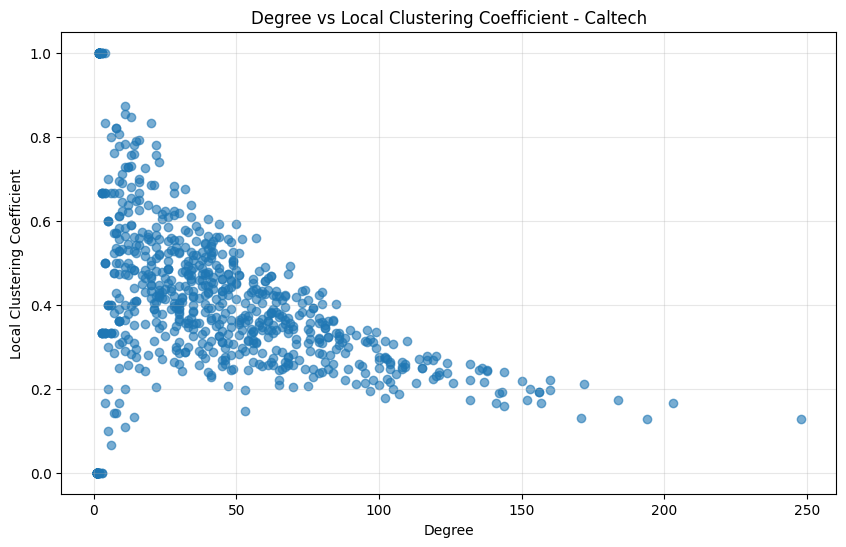

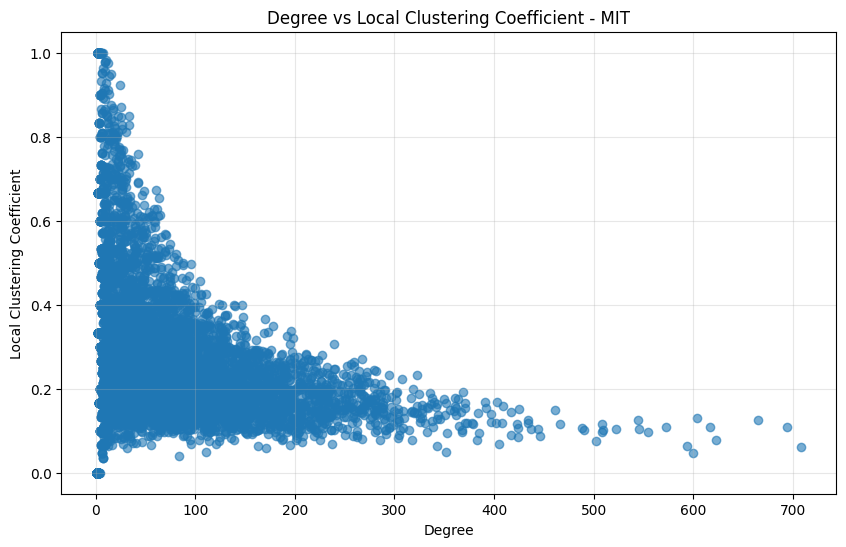

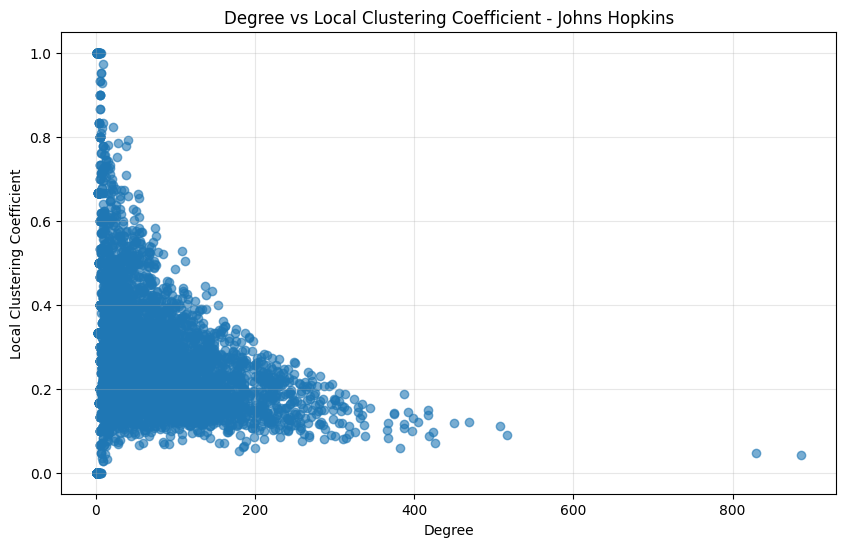

In [26]:
scatter_degree_vs_cc(GCaltech, "Caltech")
scatter_degree_vs_cc(GMIT8, "MIT")
scatter_degree_vs_cc(GHopkins, "Johns Hopkins")